Silhouette Score: 0.7493184081032155
              item_id  item_category_id  average_price
cluster                                               
0        11344.680192         45.964496     374.371946
1         6066.000000         75.000000  307980.000000
2         9672.295455         40.454545   28931.002915
3         9402.767932         40.113924   10250.422739
4         9831.663844         48.671684    2223.831891
✅ Saved K-means cluster features
Cluster distribution:
cluster
0    18336
1        1
2       44
3      237
4     3189
Name: count, dtype: int64
Best #components by BIC: 9 (BIC=-18973.79)


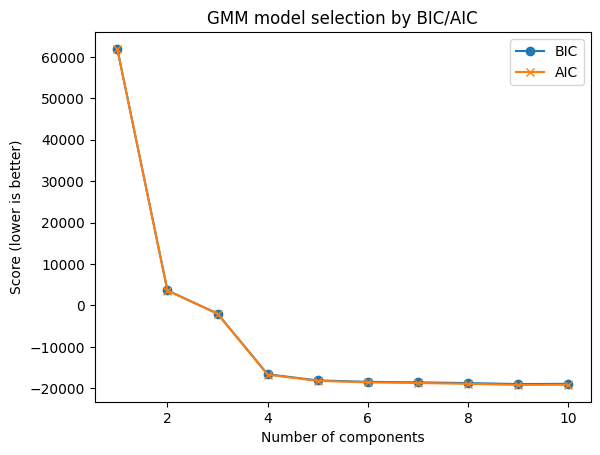

             count           mean            min            max
gmm_cluster                                                    
8            13768     225.652020       4.914856     487.235294
1             4770     843.056820     487.713225    1332.333333
7             2181    1791.971713    1334.000000    2520.326087
0              675    3273.830535    2521.148571    4626.881893
6              231    6387.838758    4644.392631    9035.972748
4              128   11744.024308    9067.600000   16578.890394
3               48   25204.518949   16790.000000   35132.857143
5                5   44734.300000   39990.500000   50999.000000
2                1  307980.000000  307980.000000  307980.000000
Silhouette Score (GMM): 0.657


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

items = pd.read_csv('input/items.csv')
shops = pd.read_csv('input/shops.csv')
cats = pd.read_csv('input/item_categories.csv')
train = pd.read_csv('input/sales_train.csv')
test = pd.read_csv('input/test.csv').set_index('ID')

items_extended = pd.merge(items, cats, on='item_category_id', how='left')
average_price = train.groupby('item_id')['item_price'].mean().reset_index()
average_price.columns = ['item_id', 'average_price']
items_extended = pd.merge(items_extended, average_price, on='item_id', how='left')

features = items_extended[['average_price']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled = features_scaled[~np.isnan(features_scaled).any(axis=1)]
items_extended = items_extended[~features.isna().any(axis=1)]

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

silhouette_avg = silhouette_score(features_scaled, clusters)
print(f'Silhouette Score: {silhouette_avg}')

items_extended['cluster'] = clusters

print(items_extended.groupby('cluster').mean(numeric_only=True))

cluster_features = items_extended[['item_id', 'cluster']].copy()
cluster_features.to_pickle("cache/cluster_features.pkl")
print("✅ Saved K-means cluster features")
print(f"Cluster distribution:\n{cluster_features['cluster'].value_counts().sort_index()}")

n_components_range = range(1, 11)

bic_list, aic_list = [], []
best_gmm, best_bic, best_n = None, np.inf, None

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="diag",   
        n_init=5,                
        reg_covar=1e-6,           
        random_state=42
    )
        
    gmm.fit(features_scaled)
    bic = gmm.bic(features_scaled)
    aic = gmm.aic(features_scaled)
    bic_list.append(bic)
    aic_list.append(aic)
    
    if bic < best_bic:
        best_bic, best_gmm, best_n = bic, gmm, n

print(f"Best #components by BIC: {best_n} (BIC={best_bic:.2f})")        

plt.figure()
plt.plot(list(n_components_range), bic_list, marker='o', label='BIC')
plt.plot(list(n_components_range), aic_list, marker='x', label='AIC')
plt.xlabel('Number of components'); plt.ylabel('Score (lower is better)')
plt.title('GMM model selection by BIC/AIC')
plt.legend() 
plt.show()

gmm_clusters = best_gmm.predict(features_scaled)

items_extended['gmm_cluster'] = gmm_clusters

summary = items_extended.groupby('gmm_cluster')['average_price'].agg(['count', 'mean', 'min', 'max']).sort_values('mean')
print(summary)

sil_gmm = silhouette_score(features_scaled, gmm_clusters)
print(f"Silhouette Score (GMM): {sil_gmm:.3f}")


